In [1]:
import sys
from pathlib import Path

# src zum Pfad hinzufügen
sys.path.insert(0, str(Path.cwd().parent / "src"))

from config import PATHS
import pandas as pd

metrics_df = pd.read_parquet(PATHS.RESULTS_DATASET)
labeled_df = pd.read_parquet(PATHS.LABELED_DATASET)

merged = metrics_df.merge(
    labeled_df[["instance_id", "resolved"]],
    on="instance_id",
    how="left",
)

clean = merged[
    merged["parsable"] 
    & merged["lm_cc"].notna() 
    & merged["resolved"].notna()
].copy()

print(f"Total: {len(merged)}")
print(f"Usable: {len(clean)}")
print(f"Resolve rate: {clean['resolved'].mean():.1%}")

Total: 427
Usable: 404
Resolve rate: 56.7%


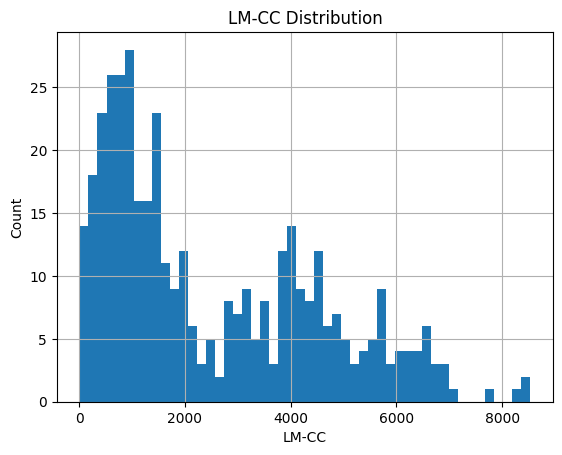

In [2]:
import matplotlib.pyplot as plt

clean["lm_cc"].describe()

clean["lm_cc"].hist(bins=50)
plt.xlabel("LM-CC")
plt.ylabel("Count")
plt.title("LM-CC Distribution")
plt.show()

In [3]:
clean[["lm_cc", "cc_sum", "loc", "halstead_volume"]].corr(method="spearman")

,lm_cc,cc_sum,loc,halstead_volume
lm_cc,1.000000,0.942164,0.958388,0.932473
cc_sum,0.942164,1.000000,0.910157,0.898672
loc,0.958388,0.910157,1.000000,0.915102
halstead_volume,0.932473,0.898672,0.915102,1.000000
